In [21]:
!pip -q install gymnasium[classic-control]
!pip -q install imageio imageio-ffmpeg

In [22]:
import random
import math
from collections import deque
import numpy as np
import matplotlib.pyplot as plt

import gymnasium as gym

import torch
import torch.nn as nn
import torch.optim as optim

from IPython.display import clear_output

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [23]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using:", device)

Using: cuda


In [24]:
env = gym.make("CartPole-v1")

state_size = env.observation_space.shape[0]
action_size = env.action_space.n

print("State Size :", state_size)
print("Action Size:", action_size)

State Size : 4
Action Size: 2


In [46]:
BUFFER_SIZE = 100000
BATCH_SIZE = 64

GAMMA = 0.99

LR = 5e-5

TAU = 0.005

EPS_START = 1.0
EPS_END = 0.01
EPS_DECAY = 0.995

TRAIN_EPISODES = 500

TARGET_UPDATE = 1

In [47]:
from collections import deque
import random

class ReplayBuffer:

    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):

        self.buffer.append(
            (state, action, reward, next_state, done)
        )

    def sample(self, batch_size):

        batch = random.sample(self.buffer, batch_size)

        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.tensor(
            np.array(states),
            dtype=torch.float32,
            device=device
        )

        actions = torch.tensor(
            actions,
            dtype=torch.long,
            device=device
        )

        rewards = torch.tensor(
            rewards,
            dtype=torch.float32,
            device=device
        )

        next_states = torch.tensor(
            np.array(next_states),
            dtype=torch.float32,
            device=device
        )

        dones = torch.tensor(
            dones,
            dtype=torch.float32,
            device=device
        )

        return (
            states,
            actions,
            rewards,
            next_states,
            dones
        )

    def __len__(self):
        return len(self.buffer)

In [48]:
memory = ReplayBuffer(100)

print(memory)

print("Replay Buffer Ready!")

Replay Buffer Ready!


In [49]:
class DQN(nn.Module):

    def __init__(self, state_size, action_size):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(state_size, 256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.ReLU(),

            nn.Linear(256, action_size)

        )

    def forward(self, x):
        return self.network(x)

In [50]:
model = DQN(state_size, action_size).to(device)

print(model)

DQN(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
)


In [51]:
state, _ = env.reset()

state = torch.tensor(
    state,
    dtype=torch.float32,
    device=device
).unsqueeze(0)

with torch.no_grad():

    q_values = model(state)

print("Q-values:", q_values)

print("Predicted Action:", torch.argmax(q_values).item())

Q-values: tensor([[-0.1064,  0.0240]], device='cuda:0')
Predicted Action: 1


In [52]:
class DDQNAgent:

    def __init__(self):

        # Networks
        self.policy_net = DQN(state_size, action_size).to(device)
        self.target_net = DQN(state_size, action_size).to(device)

        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        # Optimizer
        self.optimizer = optim.Adam(
            self.policy_net.parameters(),
            lr=LR
        )

        # Replay Buffer
        self.memory = ReplayBuffer(BUFFER_SIZE)

        # Exploration
        self.epsilon = EPS_START

        # Track training loss
        self.losses = []

    # --------------------------------------------------
    # Select Action (ε-Greedy)
    # --------------------------------------------------
    def act(self, state):

        if random.random() < self.epsilon:
            return random.randrange(action_size)

        state = torch.tensor(
            state,
            dtype=torch.float32,
            device=device
        ).unsqueeze(0)

        with torch.no_grad():
            q_values = self.policy_net(state)

        return torch.argmax(q_values).item()

    # --------------------------------------------------
    # Store Experience
    # --------------------------------------------------
    def remember(self, state, action, reward, next_state, done):

        self.memory.add(
            state,
            action,
            reward,
            next_state,
            done
        )

    # --------------------------------------------------
    # Soft Target Update
    # --------------------------------------------------
    def soft_update(self):

        for target_param, policy_param in zip(
            self.target_net.parameters(),
            self.policy_net.parameters()
        ):

            target_param.data.copy_(

                TAU * policy_param.data +

                (1.0 - TAU) * target_param.data

            )

    # --------------------------------------------------
    # Learn (Double DQN)
    # --------------------------------------------------
    def learn(self):

        if len(self.memory) < BATCH_SIZE:
            return

        states, actions, rewards, next_states, dones = \
            self.memory.sample(BATCH_SIZE)

        # Current Q-values
        current_q = self.policy_net(states).gather(
            1,
            actions.unsqueeze(1)
        ).squeeze(1)

        # Double DQN Target
        with torch.no_grad():

            next_actions = self.policy_net(next_states).argmax(dim=1)

            next_q = self.target_net(next_states).gather(
                1,
                next_actions.unsqueeze(1)
            ).squeeze(1)

            target_q = rewards + GAMMA * next_q * (1 - dones)

        loss = nn.SmoothL1Loss()(current_q, target_q)

        self.losses.append(loss.item())

        self.optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            self.policy_net.parameters(),
            10.0
        )

        self.optimizer.step()

        self.soft_update()

In [53]:
    def soft_update(self):

        for target_param, policy_param in zip(
            self.target_net.parameters(),
            self.policy_net.parameters()
        ):

            target_param.data.copy_(

                TAU * policy_param.data +

                (1.0 - TAU) * target_param.data

            )

In [54]:
agent = DDQNAgent()

In [55]:
print(hasattr(agent, "act"))
print(hasattr(agent, "remember"))
print(hasattr(agent, "learn"))
print(hasattr(agent, "soft_update"))

True
True
True
True


In [56]:
agent = DDQNAgent()

print("Policy Network:")
print(agent.policy_net)

print("\nTarget Network:")
print(agent.target_net)

print("\nAgent Ready!")

Policy Network:
DQN(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
)

Target Network:
DQN(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
)

Agent Ready!


In [57]:
reward_history = []

best_reward = -float("inf")

for episode in range(1, TRAIN_EPISODES + 1):

    state, _ = env.reset()

    done = False

    episode_reward = 0

    while not done:

        # Select action
        action = agent.act(state)

        # Step environment
        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated

        # Store experience
        agent.remember(
            state,
            action,
            reward,
            next_state,
            done
        )

        # Learn
        agent.learn()

        # Move to next state
        state = next_state

        episode_reward += reward

    # ----------------------------
    # Decay epsilon
    # ----------------------------
    agent.epsilon = max(
        EPS_END,
        agent.epsilon * EPS_DECAY
    )

    reward_history.append(episode_reward)

    # ----------------------------
    # Save best model
    # ----------------------------
    if episode_reward > best_reward:

        best_reward = episode_reward

        torch.save(
            agent.policy_net.state_dict(),
            "best_cartpole_ddqn.pth"
        )

    # ----------------------------
    # Logging
    # ----------------------------
    if episode % 10 == 0:

        avg_reward = np.mean(reward_history[-10:])

        avg_loss = (
            np.mean(agent.losses[-100:])
            if len(agent.losses) > 0
            else 0
        )

        print(
            f"Episode {episode:3d} | "
            f"Reward {episode_reward:3.0f} | "
            f"Average {avg_reward:7.2f} | "
            f"Loss {avg_loss:8.5f} | "
            f"Epsilon {agent.epsilon:.3f}"
        )

Episode  10 | Reward  16 | Average   15.80 | Loss  0.29763 | Epsilon 0.951
Episode  20 | Reward  11 | Average   20.90 | Loss  0.04750 | Epsilon 0.905
Episode  30 | Reward  15 | Average   17.50 | Loss  0.06460 | Epsilon 0.860
Episode  40 | Reward  16 | Average   15.90 | Loss  0.11351 | Epsilon 0.818
Episode  50 | Reward  16 | Average   20.50 | Loss  0.14030 | Epsilon 0.778
Episode  60 | Reward  30 | Average   19.10 | Loss  0.19859 | Epsilon 0.740
Episode  70 | Reward  22 | Average   25.80 | Loss  0.21283 | Epsilon 0.704
Episode  80 | Reward  17 | Average   16.30 | Loss  0.22865 | Epsilon 0.670
Episode  90 | Reward  39 | Average   19.10 | Loss  0.24205 | Epsilon 0.637
Episode 100 | Reward  29 | Average   19.20 | Loss  0.30887 | Epsilon 0.606
Episode 110 | Reward 110 | Average   44.90 | Loss  0.34686 | Epsilon 0.576
Episode 120 | Reward 159 | Average   88.60 | Loss  0.44519 | Epsilon 0.548
Episode 130 | Reward 156 | Average   90.50 | Loss  0.43685 | Epsilon 0.521
Episode 140 | Reward 112 

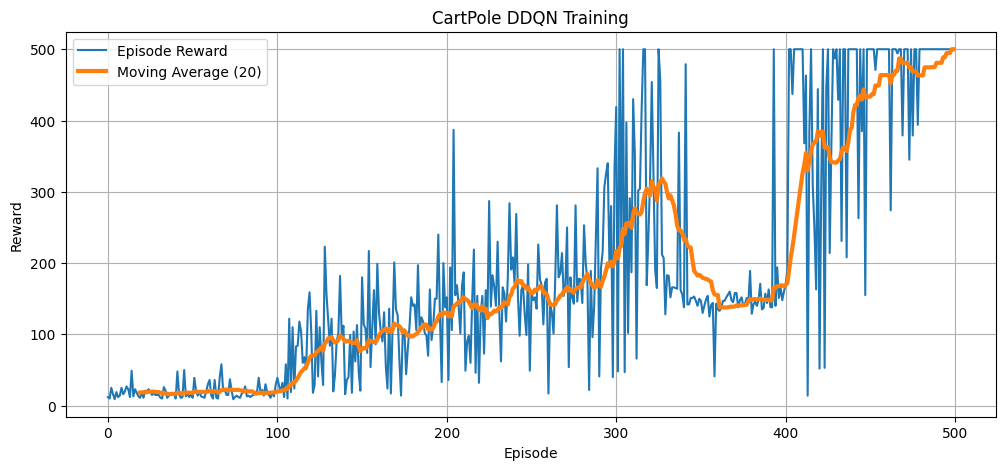

In [58]:
plt.figure(figsize=(12,5))

plt.plot(reward_history, label="Episode Reward")

window = 20

moving_avg = np.convolve(
    reward_history,
    np.ones(window)/window,
    mode="valid"
)

plt.plot(
    range(window-1, len(reward_history)),
    moving_avg,
    linewidth=3,
    label="Moving Average (20)"
)

plt.xlabel("Episode")
plt.ylabel("Reward")

plt.title("CartPole DDQN Training")

plt.legend()

plt.grid(True)

plt.show()

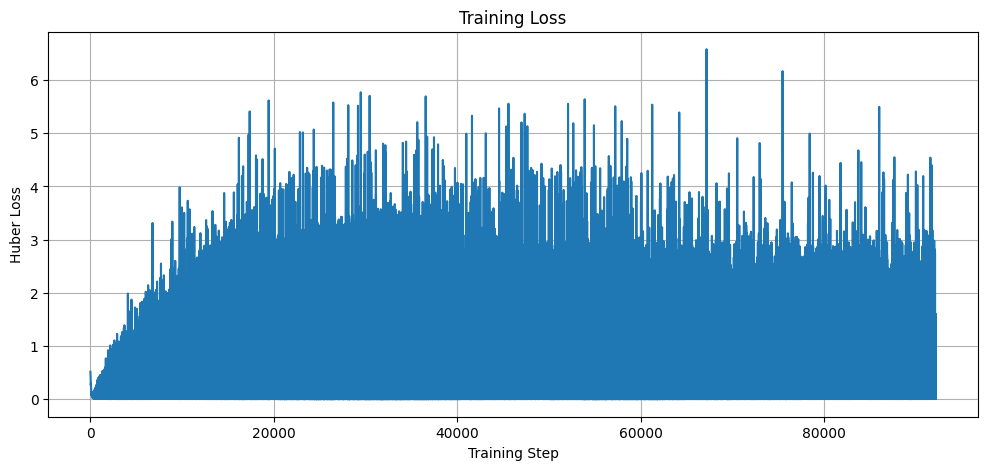

In [59]:
plt.figure(figsize=(12,5))

plt.plot(agent.losses)

plt.title("Training Loss")

plt.xlabel("Training Step")

plt.ylabel("Huber Loss")

plt.grid(True)

plt.show()

In [60]:
best_agent = DDQNAgent()

best_agent.policy_net.load_state_dict(
    torch.load(
        "best_cartpole_ddqn.pth",
        map_location=device
    )
)

best_agent.policy_net.eval()

best_agent.epsilon = 0

print("Best Model Loaded Successfully!")

Best Model Loaded Successfully!


In [61]:
evaluation_episodes = 100

scores = []

for episode in range(evaluation_episodes):

    state, _ = env.reset()

    done = False

    total_reward = 0

    while not done:

        state_tensor = torch.tensor(
            state,
            dtype=torch.float32,
            device=device
        ).unsqueeze(0)

        with torch.no_grad():
            action = torch.argmax(
                best_agent.policy_net(state_tensor)
            ).item()

        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated

        state = next_state

        total_reward += reward

    scores.append(total_reward)

print("="*50)
print("Evaluation Results")
print("="*50)

print("Average Reward :", np.mean(scores))
print("Maximum Reward :", np.max(scores))
print("Minimum Reward :", np.min(scores))
print("Success Rate   :", np.mean(np.array(scores) >= 475) * 100, "%")

Evaluation Results
Average Reward : 371.23
Maximum Reward : 500.0
Minimum Reward : 215.0
Success Rate   : 28.000000000000004 %


In [62]:
!pip -q install moviepy

In [63]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import shutil
import os

video_folder = "cartpole_video"

if os.path.exists(video_folder):
    shutil.rmtree(video_folder)

video_env = RecordVideo(
    gym.make("CartPole-v1", render_mode="rgb_array"),
    video_folder=video_folder,
    episode_trigger=lambda e: True
)

state, _ = video_env.reset()

done = False

while not done:

    state_tensor = torch.tensor(
        state,
        dtype=torch.float32,
        device=device
    ).unsqueeze(0)

    with torch.no_grad():
        action = torch.argmax(
            best_agent.policy_net(state_tensor)
        ).item()

    state, reward, terminated, truncated, _ = video_env.step(action)

    done = terminated or truncated

video_env.close()

print("Gameplay Recorded!")

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


Gameplay Recorded!


In [64]:
import os
from IPython.display import Video

video_path = None

for file in os.listdir("cartpole_video"):
    if file.endswith(".mp4"):
        video_path = os.path.join("cartpole_video", file)
        break

Video(video_path, embed=True)

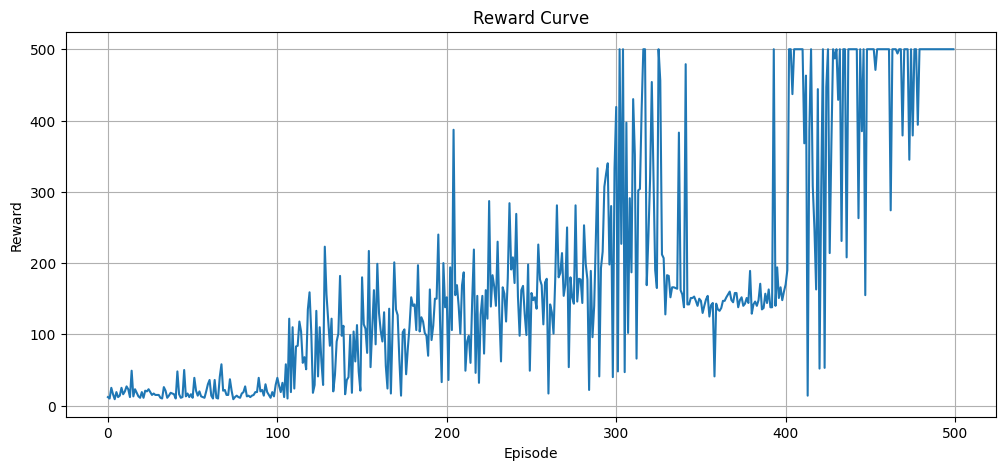

In [65]:
plt.figure(figsize=(12,5))

plt.plot(reward_history)

plt.title("Reward Curve")

plt.xlabel("Episode")

plt.ylabel("Reward")

plt.grid(True)

plt.savefig("reward_plot.png")

plt.show()

In [66]:
print("="*60)
print("CartPole Double DQN Project Summary")
print("="*60)

print(f"Training Episodes : {TRAIN_EPISODES}")
print(f"Replay Buffer     : {BUFFER_SIZE}")
print(f"Batch Size        : {BATCH_SIZE}")
print(f"Gamma             : {GAMMA}")
print(f"Learning Rate     : {LR}")
print(f"Average Reward    : {np.mean(scores):.2f}")
print(f"Maximum Reward    : {np.max(scores)}")
print(f"Success Rate      : {np.mean(np.array(scores) >= 475)*100:.2f}%")
print("="*60)

CartPole Double DQN Project Summary
Training Episodes : 500
Replay Buffer     : 100000
Batch Size        : 64
Gamma             : 0.99
Learning Rate     : 5e-05
Average Reward    : 371.23
Maximum Reward    : 500.0
Success Rate      : 28.00%
